A <span style="font-weight:600;color:darkblue;">frequency table</span> shows how often a value appears in our data.<br/>
The following lists contains the answers from a sample of 20 people, about their <span style="text-decoration:underline;">favorite fruit</span>.

In [2]:
# fmt: off
fruits = [
    "apple","banana","apple","orange","banana","banana","apple","banana","orange","apple","banana","banana","orange","apple","apple","banana","banana","apple","orange","banana"
]

#### Count frequencies for Categorical Data
##### [1] Using a `Counter` object

In [4]:
from collections import Counter

fruit_counts = Counter(fruits)
fruit_counts

Counter({'banana': 9, 'apple': 7, 'orange': 4})

The frequency table above gives us the following information:
- 9 people chose banana 🍌
- 7 people chose apple 🍎
- 4 people chose orange 🍊

##### [2] Using `value_counts()` for one way tables

In [6]:
import pandas as pd

df = pd.DataFrame({"fruit": fruits})
df["fruit"].value_counts()

fruit
banana    9
apple     7
orange    4
Name: count, dtype: int64

##### [3] Using `pd.crosstab()` for two way tables

In [7]:
df = pd.DataFrame(
    {
        "fruit": ["apple", "banana", "apple", "orange", "banana", "banana"],
        "color": ["red", "yellow", "green", "orange", "yellow", "green"],
    }
)

In [ ]:
# Groups by the values of fruit in the rows, and by the values
# of color in the columns
pd.crosstab(df["fruit"], df["color"])

color,green,orange,red,yellow
fruit,,,,
apple,1,0,1,0
banana,1,0,0,2
orange,0,1,0,0


##### Relative Frequency using `value_counts(normalize=True)`

In [12]:
import pandas as pd

df = pd.DataFrame({"fruit": fruits})
freq = df["fruit"].value_counts()
rel_freq = df["fruit"].value_counts(normalize=True)

print("Frequency:")
print(freq)
print("\nRelative Frequency:")
print(rel_freq)

Frequency:
fruit
banana    9
apple     7
orange    4
Name: count, dtype: int64

Relative Frequency:
fruit
banana    0.45
apple     0.35
orange    0.20
Name: proportion, dtype: float64


##### Cumulative Frequency for Ordered Numerical Data

In [15]:
scores = pd.Series([85, 90, 85, 88, 92, 85, 90])
freq = scores.value_counts().sort_index()
cum_freq = freq.cumsum()

print("Frequency:")
print(freq)
print("\nCumulative Frequency:")
print(cum_freq)

Frequency:
85    3
88    1
90    2
92    1
Name: count, dtype: int64

Cumulative Frequency:
85    3
88    4
90    6
92    7
Name: count, dtype: int64


##### Visualize it with a Bar Chart

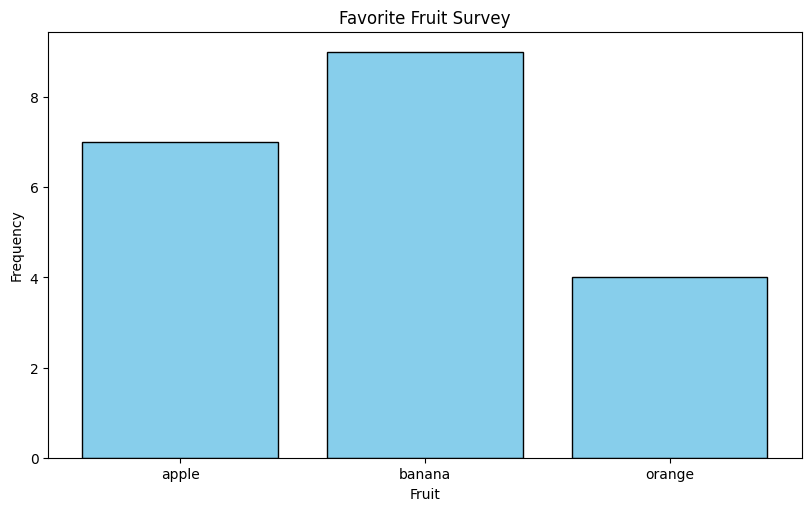

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

# Use the Counter object from the start of this tutorial
ax.bar(fruit_counts.keys(), fruit_counts.values(), color="skyblue", edgecolor="black")
ax.set_title("Favorite Fruit Survey")
ax.set_xlabel("Fruit")
ax.set_ylabel("Frequency")
plt.show()

#### Frequency Table for Numerical Data

In [31]:
import numpy as np

# Heights of 50 students, assuming a mean of 165cm and a SD of 10cm.
heights = np.random.normal(loc=165, scale=10, size=50)

# The bin edges:
bins = [140, 150, 160, 170, 180, 190]

# Frequency table using intervals
counts, bin_edges = np.histogram(heights, bins=bins)

print("Group Frequency Table:")
print("=" * 30)

for i in range(len(counts)):
    print(f"{bin_edges[i]}-{bin_edges[i+1]} : {counts[i]}")

Group Frequency Table:
140-150 : 4
150-160 : 9
160-170 : 22
170-180 : 12
180-190 : 3


From the frequency table above we conclude that:
- Most students are in the 160-170cm range
- Very few are taller than 180cm or shorter than 150cm

##### Plot it with a Histogram

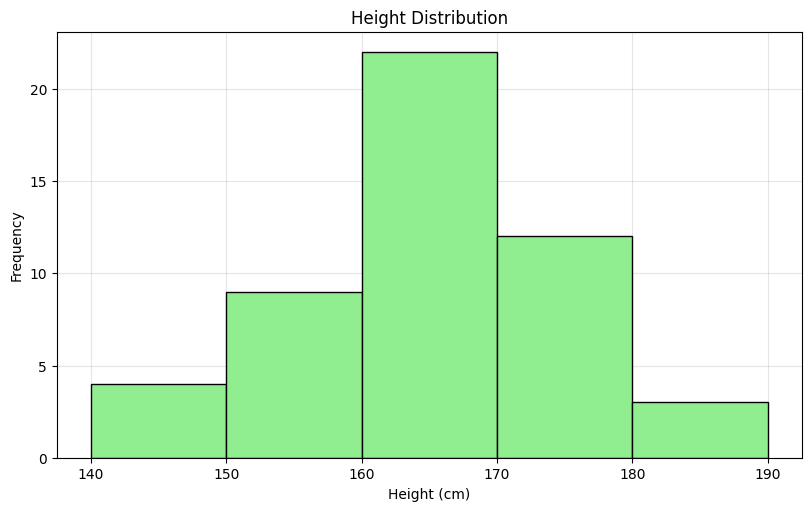

In [40]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

ax.hist(heights, bins=bins, color="lightgreen", edgecolor="black")
ax.set_title("Height Distribution")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Frequency")
ax.grid(color="gray", alpha=0.2)
ax.set_axisbelow(True)

plt.show()

<pre style="font:normal 14pt/1.3 consolas">
<b>NOTE:</b> <span style="color:lightgreen">histograms</span> have connected bars - continuous data, while
      <span style="color:skyblue">bar charts</span> have discrete bars - separate categories
</pre>

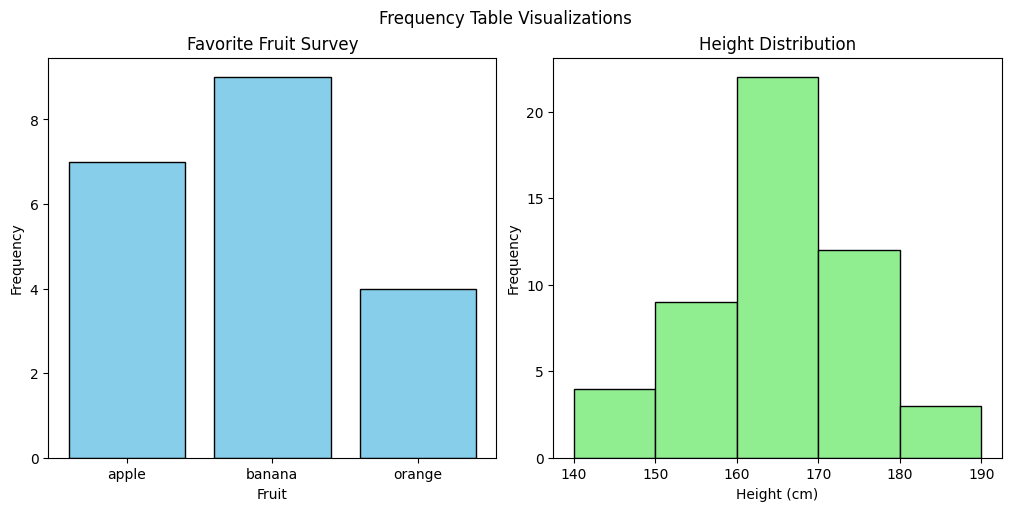

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")
fig.suptitle("Frequency Table Visualizations")

ax1.bar(fruit_counts.keys(), fruit_counts.values(), color="skyblue", edgecolor="black")
ax1.set_title("Favorite Fruit Survey")
ax1.set_xlabel("Fruit")
ax1.set_ylabel("Frequency")

ax2.hist(heights, bins=bins, color="lightgreen", edgecolor="black")
ax2.set_title("Height Distribution")
ax2.set_xlabel("Height (cm)")
ax2.set_ylabel("Frequency")

plt.show()